In [1]:
import re
import pandas as pd

# The stable, clean regex for standard messages
pattern = r'^(\d{1,2}/\d{1,2}/\d{2,4}, \d{1,2}:\d{2}\s?[aApP][mM]) - (.*?): (.*)'

# A secondary check just to identify system timestamps
system_msg_pattern = r'^(\d{1,2}/\d{1,2}/\d{2,4}, \d{1,2}:\d{2}\s?[aApP][mM])'

def parse_and_anonymize_chat(file_path):
    parsed_data = []
    name_map = {}
    user_counter = 1
    
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            line = line.replace('\u200e', '').replace('\u200f', '').strip() 
            if not line:
                continue 
            
            # Tier 1: Is it a normal text message?
            match = re.match(pattern, line)
            if match:
                date_time = match.group(1)
                sender_real_name = match.group(2)
                message = match.group(3)
                
                # Auto-Anonymization
                if sender_real_name not in name_map:
                    name_map[sender_real_name] = f"Person_{user_counter}"
                    user_counter += 1
                
                sender_alias = name_map[sender_real_name]
                
                # Filter media
                if "Media omitted" in message or "<Media omitted>" in message:
                    continue
                    
                parsed_data.append([date_time, sender_alias, message])
            else:
                # Tier 2: The Rejected Line Check
                # If it starts with a timestamp but has no colon, it's a system message. Skip it entirely.
                if re.match(system_msg_pattern, line):
                    continue
                
                # If it doesn't start with a timestamp, it's a genuine continuation of the previous text
                if len(parsed_data) > 0:
                    parsed_data[-1][2] += " " + line
                    
    return pd.DataFrame(parsed_data, columns=['DateTime', 'Sender', 'Message'])

# Run the updated parser
df = parse_and_anonymize_chat('raw_chat.txt') 

# Display results
print(f"Total messages successfully parsed: {len(df)}")
df.head()

Total messages successfully parsed: 2434


,DateTime,Sender,Message
0,"31/10/25, 5:34 pm",Person_1,Photos????
1,"01/11/25, 2:23 pm",Person_3,Everyone make sure you complete the math assig...
2,"01/11/25, 2:23 pm",Person_4,this is assignment?
3,"01/11/25, 2:23 pm",Person_3,Illa da this is hw
4,"01/11/25, 2:23 pm",Person_3,Assignment gcr la Irukku


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. NEW FILTERING LOGIC: Keep ONLY the Top 5 most active people
# This eliminates the "ghosts" and forces the AI to focus on the core speakers
top_5_senders = df['Sender'].value_counts().head(5).index
df_filtered = df[df['Sender'].isin(top_5_senders)]

print("Filtering dataset to the 5 most active members...")
print(df_filtered['Sender'].value_counts())
print(f"\nRetained {len(df_filtered)} messages out of {len(df)} total.\n")

# 2. Isolate features (X) and target labels (y) using the newly filtered data
X = df_filtered['Message']  
y = df_filtered['Sender']   

# 3. Split into Train and Test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Training messages: {X_train.shape[0]}")
print(f"Testing messages: {X_test.shape[0]}\n")

# 4. Initialize and fit the TF-IDF Vectorizer with a Custom Blacklist
custom_blacklist = ['adithyan', 'amma']
vectorizer = TfidfVectorizer(sublinear_tf=True, lowercase=True, stop_words=custom_blacklist)
X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)

print(f"Vocabulary size (Total unique features learned): {len(vectorizer.get_feature_names_out())}")
print(f"Shape of training matrix: {X_train_vectors.shape}")

Filtering dataset to the 5 most active members...
Sender
Person_3     717
Person_6     170
Person_2     170
Person_49    103
Person_12     99
Name: count, dtype: int64

Retained 1259 messages out of 2434 total.

Training messages: 1007
Testing messages: 252

Vocabulary size (Total unique features learned): 2100
Shape of training matrix: (1007, 2100)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. The Upgrade: Logistic Regression with Balanced Weights
# max_iter=1000 gives the math engine enough time to converge on the right answers
classifier = LogisticRegression(class_weight='balanced', max_iter=1000)

# 2. Train the New Model
print("Training the Balanced Logistic Regression model...")
classifier.fit(X_train_vectors, y_train)
print("Training complete!\n")

# 3. The Final Exam
y_predictions = classifier.predict(X_test_vectors)

# 4. Grading the Exam
accuracy = accuracy_score(y_test, y_predictions)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n")

# 5. The Detailed Report Card
print("Detailed Classification Report:")
print(classification_report(y_test, y_predictions))

Training the Balanced Logistic Regression model...
Training complete!

Overall Model Accuracy: 58.73%

Detailed Classification Report:
              precision    recall  f1-score   support

   Person_12       0.21      0.35      0.26        20
    Person_2       0.63      0.56      0.59        34
    Person_3       0.77      0.73      0.75       143
   Person_49       0.32      0.29      0.30        21
    Person_6       0.34      0.35      0.35        34

    accuracy                           0.59       252
   macro avg       0.45      0.45      0.45       252
weighted avg       0.61      0.59      0.60       252



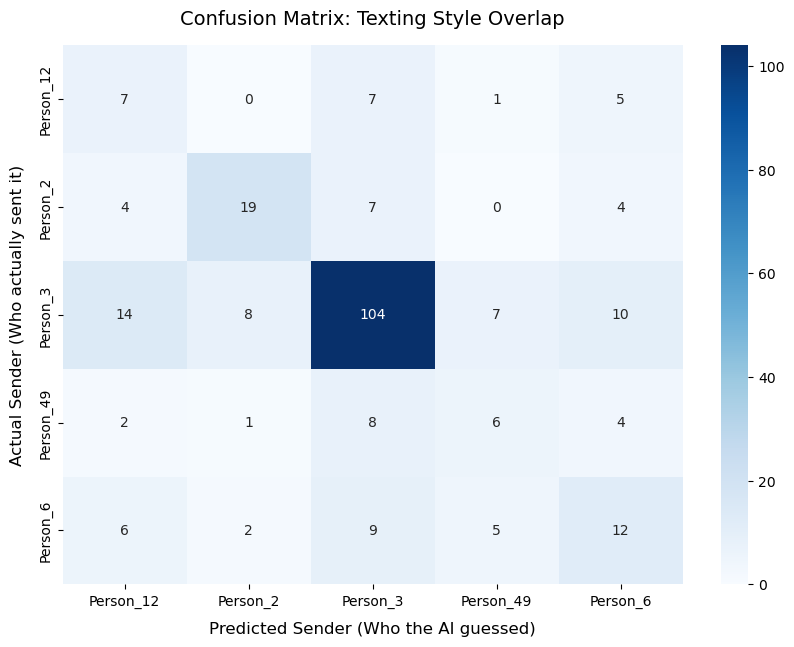

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the raw matrix data
cm = confusion_matrix(y_test, y_predictions, labels=classifier.classes_)

# 2. Plot the Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classifier.classes_, 
            yticklabels=classifier.classes_)

# 3. Add professional labels
plt.title('Confusion Matrix: Texting Style Overlap', fontsize=14, pad=15)
plt.xlabel('Predicted Sender (Who the AI guessed)', fontsize=12, labelpad=10)
plt.ylabel('Actual Sender (Who actually sent it)', fontsize=12, labelpad=10)

# Display the chart
plt.show()

In [14]:
import numpy as np

# 1. Get the vocabulary (the 3,024 unique words the model learned)
feature_names = vectorizer.get_feature_names_out()

# 2. Get the mathematical weights the AI assigned
coefficients = classifier.coef_

print("🔥 THE SIGNATURE VOCABULARY 🔥\n" + "="*30)

# 3. Loop through every person in your Top 5
for i, person in enumerate(classifier.classes_):
    person_weights = coefficients[i]
    
    # Sort the words by weight (lowest to highest), grab the last 10, and flip them (highest to lowest)
    top_words_indices = person_weights.argsort()[-10:][::-1]
    
    print(f"\n{person}'s Signature Words:")
    for index in top_words_indices:
        word = feature_names[index]
        weight = person_weights[index]
        print(f"  - {word} (Score: {weight:.2f})")

🔥 THE SIGNATURE VOCABULARY 🔥

Person_12's Signature Words:
  - you (Score: 1.96)
  - got (Score: 1.60)
  - yeahh (Score: 1.52)
  - why (Score: 1.33)
  - let (Score: 1.31)
  - try (Score: 1.31)
  - box (Score: 1.30)
  - what (Score: 1.23)
  - ig (Score: 1.23)
  - its (Score: 1.21)

Person_2's Signature Words:
  - bro (Score: 2.05)
  - tmr (Score: 1.97)
  - ye (Score: 1.60)
  - then (Score: 1.39)
  - wat (Score: 1.35)
  - nah (Score: 1.31)
  - ille (Score: 1.13)
  - first (Score: 1.11)
  - 91 (Score: 1.11)
  - ya (Score: 1.08)

Person_3's Signature Words:
  - aah (Score: 1.27)
  - da (Score: 1.15)
  - everyone (Score: 0.95)
  - dei (Score: 0.88)
  - please (Score: 0.88)
  - dhan (Score: 0.77)
  - are (Score: 0.76)
  - your (Score: 0.75)
  - sign (Score: 0.74)
  - im (Score: 0.73)

Person_49's Signature Words:
  - yep (Score: 1.87)
  - event (Score: 1.62)
  - panunga (Score: 1.56)
  - asap (Score: 1.53)
  - register (Score: 1.52)
  - ah (Score: 1.41)
  - 30 (Score: 1.38)
  - tha (Score: 1

## Section 4: Real-Time Model Inference
The true test of an NLP model is its ability to classify unseen data on the fly. 
Below is a deployment-ready function that takes raw text, vectorizes it, and outputs a prediction alongside a mathematical confidence score. 

Feel free to change the text in the `guess_who_said_this()` function below to test the AI's understanding of the group's texting habits!

In [16]:
def guess_who_said_this(fake_message):
    # 1. Clean and transform the new message into math
    # Notice we use .transform(), NOT .fit_transform(), so we don't overwrite the brain!
    message_vector = vectorizer.transform([fake_message])
    
    # 2. The AI makes its prediction
    prediction = classifier.predict(message_vector)[0]
    
    # 3. The AI calculates its confidence score (probability)
    probabilities = classifier.predict_proba(message_vector)[0]
    confidence = max(probabilities) * 100
    
    print("-" * 50)
    print(f"💬 Message: '{fake_message}'")
    print(f"🤖 AI Prediction: {prediction}")
    print(f"📊 Confidence: {confidence:.2f}%")
    print("-" * 50)

# --- PLAY THE GAME HERE ---
# Change the text inside the quotes to test your gang's different styles!

guess_who_said_this("bro tmr what time is the assignment due??")
guess_who_said_this("👍")

--------------------------------------------------
💬 Message: 'bro tmr what time is the assignment due??'
🤖 AI Prediction: Person_2
📊 Confidence: 41.47%
--------------------------------------------------
--------------------------------------------------
💬 Message: '👍'
🤖 AI Prediction: Person_3
📊 Confidence: 29.28%
--------------------------------------------------
